# Evaluate: pitch-class-profile query-by-humming matching

Compares subsequence-DTW query-by-humming matching using a 24-class (sruti-resolution, 50 cents each) pitch-class salience profile, at several Gaussian blur widths. Queries and reference songs are already on disk under `data/queries/` and `data/references/`; each song's vocals are isolated with Demucs before pitch extraction.

Every pitch is folded mod 1200 cents (its position within an octave), so the profile is octave- and transposition-invariant by construction: matching tries 12 circular shifts of the reference profile, two classes (100 cents, a semitone) apart, and keeps the best. Each shift is a single ordinary subsequence DTW over the *entire, un-windowed* reference -- no per-window re-centring and no explicit tempo resampling are needed, since subsequence DTW already finds the best-aligned subsequence anywhere in the reference in one pass, and its own warping path absorbs tempo differences.

In [7]:
%matplotlib inline
import time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import plots, utils
from tqdm.auto import tqdm

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
plots.set_style(PALETTE)

DATA_ROOT = Path("data")
CACHE_ROOT = Path(".cache")
PITCH = {"sr": 22050, "fmin": 80.0, "fmax": 1000.0, "frame_length": 2048, "hop_seconds": 0.025}
EVAL = {"hop_seconds": 0.1, "f_ref": 55.0, "n_classes": 24, "shift_step": 2}
N_QUERIES = None
SIGMAS = [0, 25, 50, 100, 150, 200]

## Load pitch tracks

In [8]:
index = pd.read_csv(DATA_ROOT / "queries_index.csv")
if N_QUERIES:
    index = index.sample(N_QUERIES, random_state=0).reset_index(drop=True)

query_cache = CACHE_ROOT / "pitch" / "queries"
ref_cache = CACHE_ROOT / "pitch" / "references"
demucs_cache = CACHE_ROOT / "demucs"

query_tracks = {k: utils.extract_f0(p, query_cache, PITCH) for k, p in zip(index.query_id, DATA_ROOT / index.path)}

reference_vocals = {sid: utils.separate_vocals(DATA_ROOT / "references" / f"{sid}.wav", demucs_cache)
                    for sid in tqdm(index.song_id.unique(), desc="separating vocals")}
ref_tracks = {sid: utils.extract_f0(path, ref_cache / str(sid), PITCH)
              for sid, path in tqdm(reference_vocals.items(), desc="pYIN (references)")}

len(query_tracks), len(ref_tracks)

separating vocals:   0%|          | 0/55 [00:00<?, ?it/s]

pYIN (references):   0%|          | 0/55 [00:00<?, ?it/s]

(86, 55)

## Build the pitch-class profiles

In [9]:
q_cents = [utils.downsampled_cents(query_tracks[k], EVAL, PITCH) for k in index.query_id]
r_cents = {sid: utils.downsampled_cents(t, EVAL, PITCH) for sid, t in ref_tracks.items()}
true_ids = index.song_id.astype(int).tolist()

def profiles(sigma):
    return ([utils.to_pitch_class_profile(c, EVAL["n_classes"], sigma) for c in q_cents],
            {sid: utils.to_pitch_class_profile(c, EVAL["n_classes"], sigma) for sid, c in r_cents.items()})

## Example representations

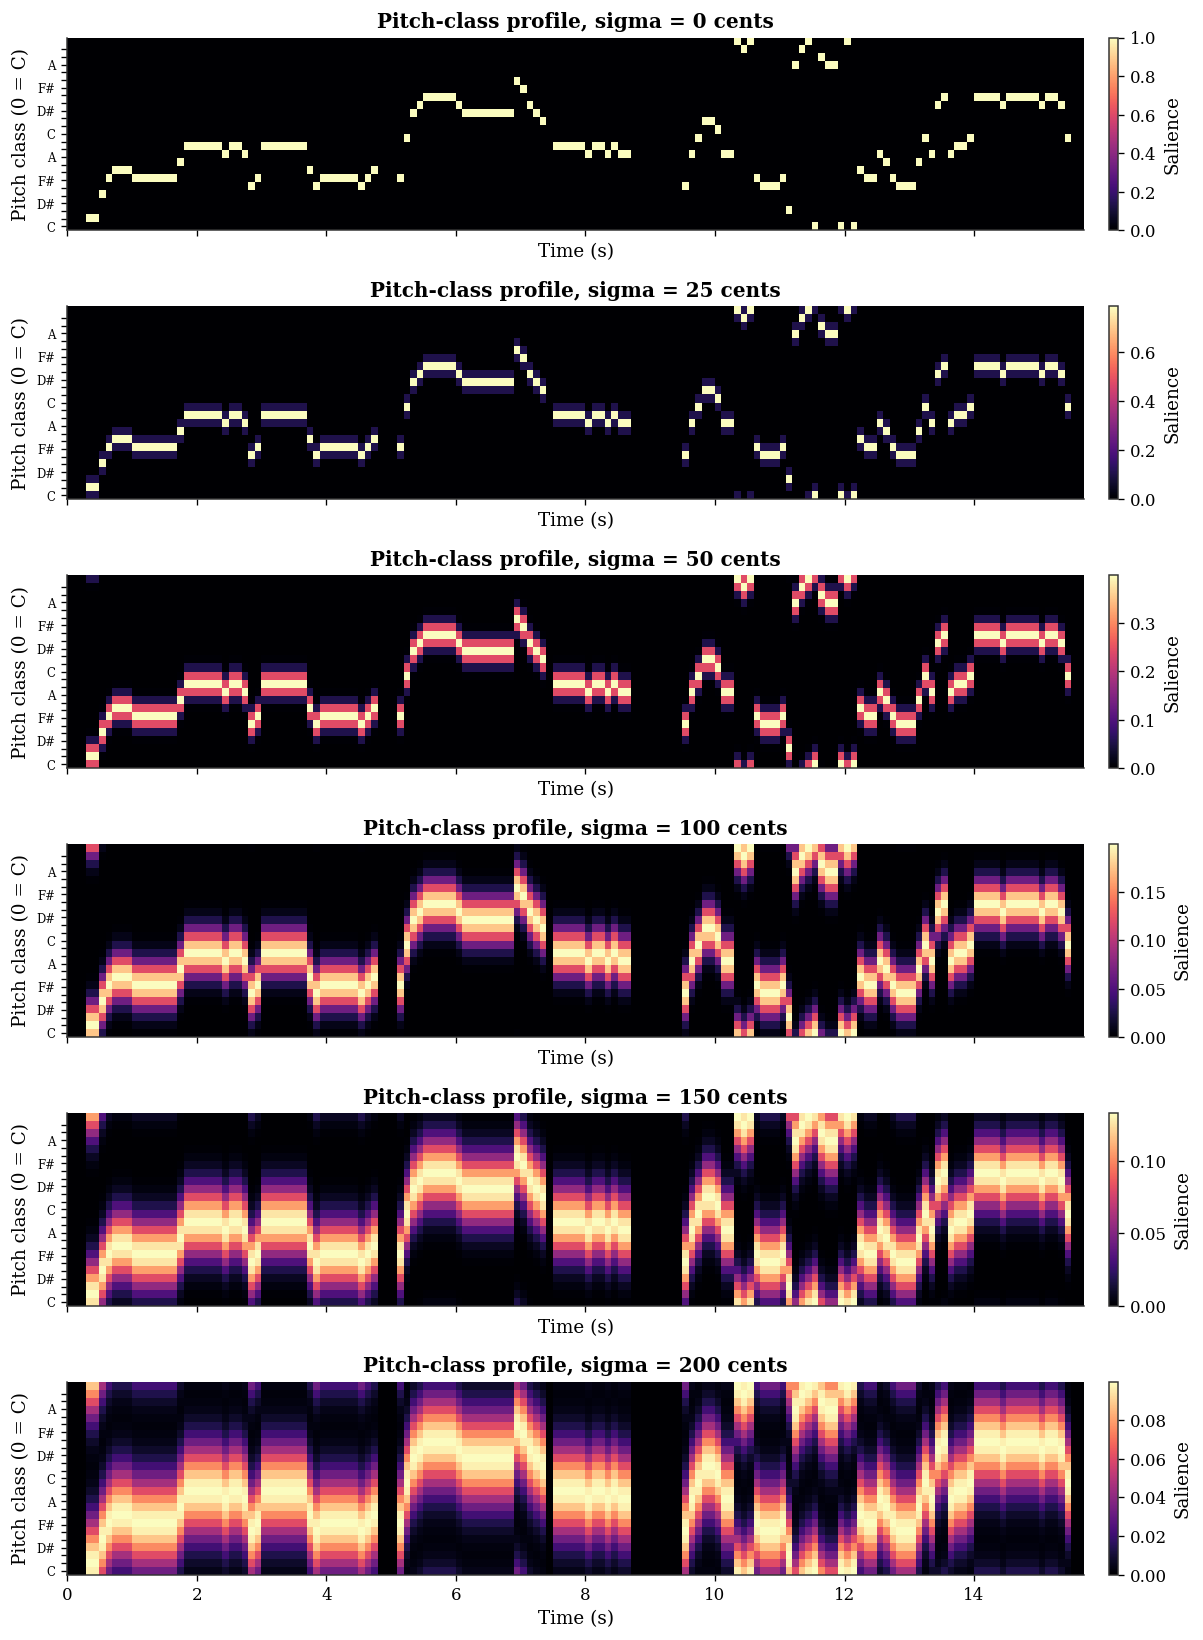

In [10]:
example_query = 0
fig, axes = plt.subplots(len(SIGMAS), 1, figsize=(11, 2.3 * len(SIGMAS)), sharex=True)
for ax, sigma in zip(np.atleast_1d(axes), SIGMAS):
    plots.plot_pitch_class_profile(ax, utils.to_pitch_class_profile(q_cents[example_query], EVAL["n_classes"], sigma),
                                    EVAL, title=f"Pitch-class profile, sigma = {sigma} cents")
axes[-1].set_xlabel("Time (s)")
fig.tight_layout()

## Rank queries under each representation

Each query-reference pair costs 12 ordinary subsequence-DTW passes (one per transposition) over the whole reference; roughly 1.5-4 s per pair depending on the reference's length. Every cost is cached to `.cache/eval/<name>.csv` as soon as it's computed, so interrupting this cell and re-running it later resumes from wherever it stopped instead of starting over. Set `N_QUERIES` to subsample while iterating.

**Rank.** For query $q$ with true song $s^*$, scored against every candidate song $s \in \mathcal{S}$ by cost $c(q, s)$ (lower is a better match):
$$
\mathrm{rank}(q) = 1 + \left|\{\, s \in \mathcal{S} : c(q, s) < c(q, s^*) \,\}\right|
$$
i.e. 1 plus the number of candidates that scored strictly better than the true song.

**Top-$k$ accuracy**, over $N$ queries $q_1, \dots, q_N$:
$$
\text{top-}k = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\!\left[\mathrm{rank}(q_i) \le k\right]
$$

**MRR (Mean Reciprocal Rank).** Rewards the true song being *near* the top even when it isn't first:
$$
\mathrm{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\mathrm{rank}(q_i)}
$$

In [11]:
results = {}
eval_cache = CACHE_ROOT / "eval"

def evaluate(name, query_reprs, refs):
    t0 = time.perf_counter()
    ranks, costs, song_ids = utils.rank_queries(
        query_reprs, refs, true_ids, desc=name,
        cost=lambda q, r: utils.transposed_subsequence_cost(q, r, EVAL["n_classes"], "cityblock",
                                                     EVAL["shift_step"]),
        query_ids=index.query_id, cache_path=eval_cache / f"{name}.csv")
    results[name] = {"ranks": ranks, "costs": costs, "song_ids": song_ids,
                     "seconds": (time.perf_counter() - t0) / len(query_reprs)}

for sigma in SIGMAS:
    q_prof, r_prof = profiles(sigma)
    evaluate(f"sigma={sigma}", q_prof, r_prof)

table = pd.DataFrame({
    name: {**utils.summarise(r["ranks"]), "seconds / query": r["seconds"]}
    for name, r in results.items()
}).T
table

sigma=0:   0%|          | 0/86 [00:00<?, ?it/s]

sigma=25:   0%|          | 0/86 [00:00<?, ?it/s]

sigma=50:   0%|          | 0/86 [00:00<?, ?it/s]

sigma=100:   0%|          | 0/86 [00:00<?, ?it/s]

sigma=150:   0%|          | 0/86 [00:00<?, ?it/s]

sigma=200:   0%|          | 0/86 [00:00<?, ?it/s]

,top-1,top-3,top-5,top-10,MRR,median rank,mean rank,seconds / query
sigma=0,0.046512,0.116279,0.162791,0.279070,0.129437,20.0,24.267442,0.000244
sigma=25,0.081395,0.162791,0.220930,0.325581,0.165086,20.0,23.220930,0.000217
sigma=50,0.372093,0.511628,0.558140,0.651163,0.474320,3.0,10.337209,0.000212
sigma=100,0.581395,0.674419,0.709302,0.813953,0.653899,1.0,6.953488,0.000209
sigma=150,0.593023,0.686047,0.709302,0.813953,0.662677,1.0,6.639535,10.021670
sigma=200,0.523256,0.686047,0.720930,0.802326,0.619137,1.0,6.825581,0.000206


## Top-k accuracy and cumulative accuracy

**CMC (Cumulative Match Characteristic) curve.** Top-$k$ accuracy evaluated at every $k$ from 1 to $|\mathcal{S}|$, i.e. the same quantity as top-$k$ accuracy above, but as a function of $k$ rather than a single number:
$$
\mathrm{CMC}(k) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}\!\left[\mathrm{rank}(q_i) \le k\right], \qquad k = 1, \dots, |\mathcal{S}|
$$
A representation that dominates another's CMC curve at every $k$ is unambiguously better; curves that cross trade off early precision against how bad the worst failures are.

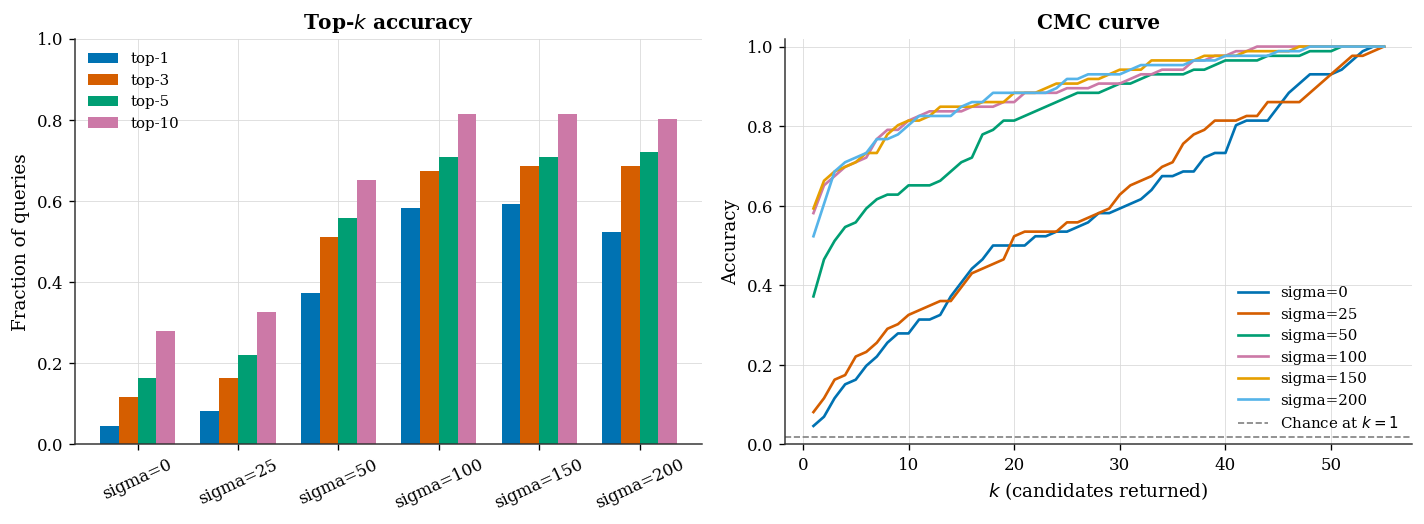

In [12]:
ranks_by_name = {name: r["ranks"] for name, r in results.items()}
n_candidates = len(next(iter(results.values()))["song_ids"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plots.plot_top_k_bar(axes[0], table)
plots.plot_cmc_curve(axes[1], ranks_by_name, n_candidates)
fig.tight_layout()

## Mean reciprocal rank, rank histogram and timing

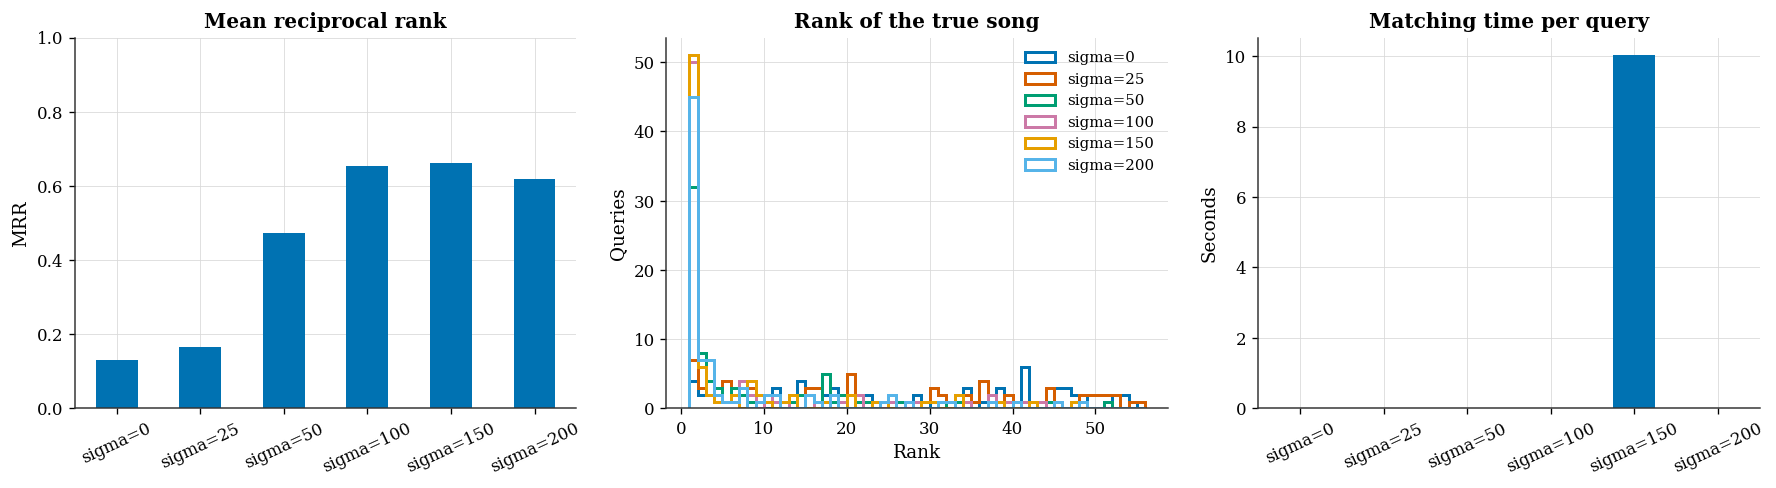

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plots.plot_mrr_bar(axes[0], table)
plots.plot_rank_histogram(axes[1], ranks_by_name, n_candidates)
plots.plot_timing_bar(axes[2], table)
fig.tight_layout()

## Genuine vs. impostor cost distributions

**Genuine vs. impostor costs.** For each query $q_i$, its cost against its own true song is *genuine*, and its cost against every other song is an *impostor* cost:
$$
c_{\text{genuine}} = \{\, c(q_i, s_i^*) \,\}_{i=1}^{N}, \qquad
c_{\text{impostor}} = \{\, c(q_i, s) : s \in \mathcal{S},\ s \ne s_i^* \,\}_{i=1}^{N}
$$
A representation that separates melodies well should push these two distributions apart.

**Separation AUC.** The probability that a random genuine cost is lower than a random impostor cost:
$$
\mathrm{AUC} = P\!\left(c_{\text{genuine}} < c_{\text{impostor}}\right) = 1 - \frac{U}{n_{\text{genuine}} \, n_{\text{impostor}}}
$$
where $U$ is the Mann-Whitney $U$ statistic between the two samples; $\mathrm{AUC} = 1$ means perfect separation (every genuine cost beats every impostor cost), $\mathrm{AUC} = 0.5$ means the two distributions are indistinguishable.

{'sigma=0': 0.5108041383730946,
 'sigma=25': 0.539733689882419,
 'sigma=50': 0.6823933858141538,
 'sigma=100': 0.7720439476794263,
 'sigma=150': 0.7770291248522725,
 'sigma=200': 0.7735462612423132}

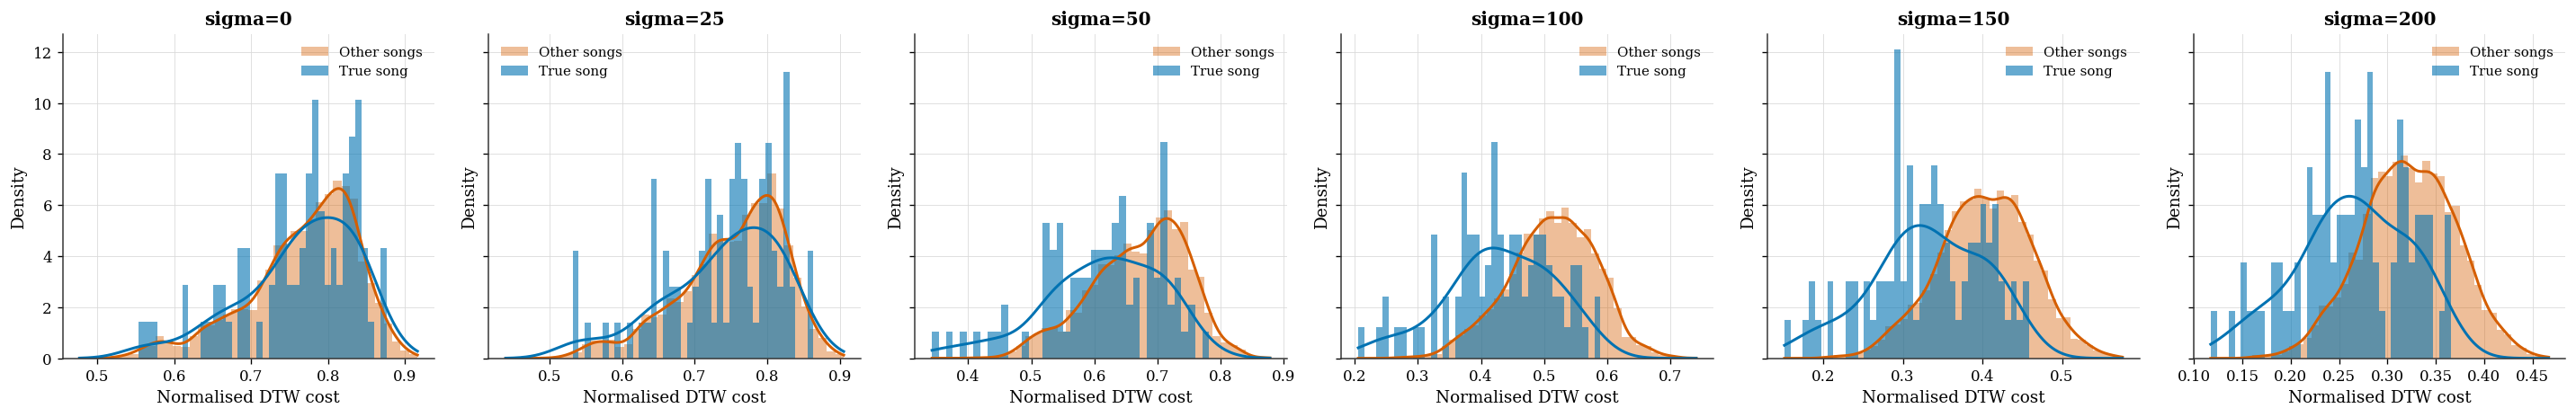

In [14]:
costs_by_name = {name: r["costs"] for name, r in results.items()}
true_cols = np.array([next(iter(results.values()))["song_ids"].index(t) for t in true_ids])

fig, axes = plt.subplots(1, len(costs_by_name), figsize=(4 * len(costs_by_name), 4), sharey=True)
auc = plots.plot_cost_distributions(axes, costs_by_name, true_cols,
                                     genuine_color=PALETTE[0], impostor_color=PALETTE[1])
fig.tight_layout()
auc

## Paired comparison: no blur vs. the best blur width

**Win / tie / loss**, per query $q_i$ comparing representations $A$ and $B$ by the true song's rank under each:
$$
\text{outcome}(q_i) =
\begin{cases}
B \text{ better} & \mathrm{rank}_B(q_i) < \mathrm{rank}_A(q_i) \\
\text{tie} & \mathrm{rank}_B(q_i) = \mathrm{rank}_A(q_i) \\
A \text{ better} & \mathrm{rank}_B(q_i) > \mathrm{rank}_A(q_i)
\end{cases}
$$

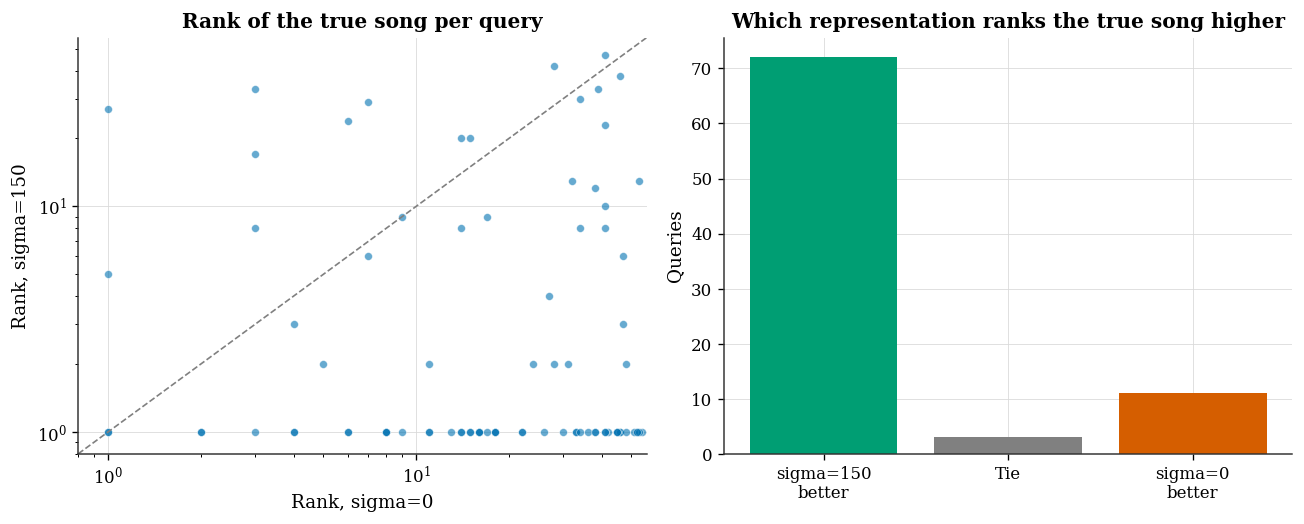

In [15]:
no_blur = f"sigma={SIGMAS[0]}"
best = table["MRR"].idxmax()

fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(11, 4.5))
plots.plot_paired_ranks(ax_scatter, ax_bar,
                         ranks_by_name[no_blur], ranks_by_name[best],
                         no_blur, best, n_candidates,
                         point_color=PALETTE[0], better_color=PALETTE[2],
                         worse_color=PALETTE[1], tie_color="gray")
fig.tight_layout()

## Which queries fail with the best setting?

A query is a **failure** under representation $R$ if its true song isn't ranked first:
$$
\mathrm{rank}_R(q) > 1
$$

In [16]:
failed = index.assign(rank_no_blur=ranks_by_name[no_blur], rank_best=ranks_by_name[best])
failed = failed[failed.rank_best > 1].sort_values("rank_best", ascending=False)
print(f"{len(failed)} of {len(index)} queries not ranked first by {best}")
failed[["query_id", "title", "original_artist", "song_id", "rank_no_blur", "rank_best"]].head(15)

35 of 86 queries not ranked first by sigma=150


,query_id,title,original_artist,song_id,rank_no_blur,rank_best
74,q103,What a wonderful world,Louis Armstrong,1835,41,47
69,q97,Imagine,John Lennon,768,28,42
57,q77,Help,The Beatles,668,46,38
5,q7,The boxer,Simon and Garfunkel,2179,39,33
24,q33,My Sharona,The Knack,2031,3,33
12,q17,Cuando los angeles lloran,Mana,96,34,30
21,q29,Nothing else matters,Metallica,1194,7,29
84,q116,You really got me,The Kinks,2024,1,27
30,q40,Yellow submarine,The Beatles,1592,6,24
72,q100,Smoke on the water,Deep Purple,1510,41,23
